# A1 — Corpus Exploration · PaperScholar (G19)

Corpus: **SciEGQA-Bench**, pinned revision `9bdca77be633cc3259d7e3739d35b38ab00bf5d9`.
Rebuild it with `bash scripts/get_data.sh` before running this notebook.

Every number in `data/provenance.md`, `grading_kit/manifest.yaml`, and the A1/A2 forms
is produced here. Nothing is estimated.

**This notebook also corrects A1.** A1's Section 3 reported corpus statistics that were
estimates presented as measurements; the measured values are shown against the claimed
ones in the final section. The three A1 *choices* — domain, data speciality, and the
robustness NFR with its `F1(S1) − F1(S3) ≤ 8` target — are unchanged.

In [1]:
import json, os, re, collections, statistics
import matplotlib.pyplot as plt

ROOT = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd()
RAW  = os.path.join(ROOT, "data", "raw")
FIGS = os.path.join(ROOT, "reports", "figures")
os.makedirs(FIGS, exist_ok=True)

pages = [json.loads(l) for l in open(os.path.join(RAW, "manifest.jsonl"), encoding="utf-8")]
qa    = [json.loads(l) for l in open(os.path.join(RAW, "qa.jsonl"),       encoding="utf-8")]
splits = json.load(open(os.path.join(RAW, "splits.json"), encoding="utf-8"))

plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
print(f"{len(pages)} pages | {len(qa)} QA pairs | {len(set(splits.values()))} splits")

1823 pages | 1623 QA pairs | 3 splits


## 1. Scale — does the corpus clear the floors?

In [2]:
n_docs  = len({p["doc_id"] for p in pages})
n_pages = len(pages)
n_words = sum(p["n_words"] for p in pages)
disk = sum(os.path.getsize(os.path.join(RAW, p["image_path"])) for p in pages)

print(f"documents          {n_docs:>10,}")
print(f"pages              {n_pages:>10,}   floor 300     {'PASS' if n_pages>=300 else 'FAIL'}")
print(f"words              {n_words:>10,}   floor 60,000  {'PASS' if n_words>=60000 else 'FAIL'}")
print(f"rendered on disk   {disk/2**30:>10.2f} GB  (300 DPI greyscale PNG)")
print(f"QA pairs           {len(qa):>10,}")
print(f"evidence pages     {len({p for q in qa for p in q['page_ids']}):>10,}")

assert n_pages >= 300 and n_words >= 60000

documents                  80
pages                   1,823   floor 300     PASS
words                 788,265   floor 60,000  PASS
rendered on disk         0.58 GB  (300 DPI greyscale PNG)
QA pairs                1,623
evidence pages            837


## 2. Subject balance

A1 claimed cs dominated at ≈61% of documents. It does not.

category    docs    share   pages
cs            10    12.5%     226
econ          10    12.5%     230
eess          10    12.5%     146
math          10    12.5%     322
physics       10    12.5%     180
q-bio         10    12.5%     162
q-fin         10    12.5%     231
stat          10    12.5%     326


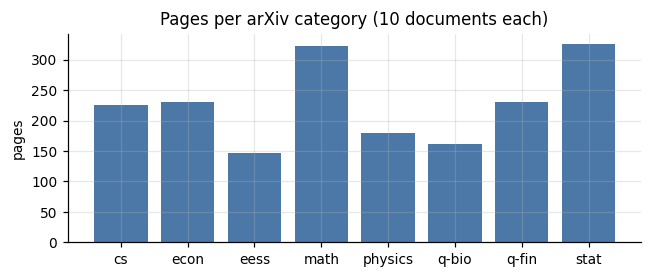

In [3]:
docs_per_cat = collections.Counter()
seen = set()
for p in pages:
    if p["doc_id"] not in seen:
        seen.add(p["doc_id"]); docs_per_cat[p["category"]] += 1
pages_per_cat = collections.Counter(p["category"] for p in pages)

print(f"{'category':<10}{'docs':>6}{'share':>9}{'pages':>8}")
for c, n in sorted(docs_per_cat.items()):
    print(f"{c:<10}{n:>6}{100*n/n_docs:>8.1f}%{pages_per_cat[c]:>8}")

fig, ax = plt.subplots(figsize=(6, 2.6))
cats = sorted(pages_per_cat)
ax.bar(cats, [pages_per_cat[c] for c in cats], color="#4C78A8")
ax.set_ylabel("pages"); ax.set_title("Pages per arXiv category (10 documents each)")
plt.tight_layout(); plt.savefig(os.path.join(FIGS, "eda_categories.png")); plt.show()

## 3. Page length

mean 432 | median 419 | p10 189 | p90 712 | max 1614
pages with <20 words: 13 (0.7%)


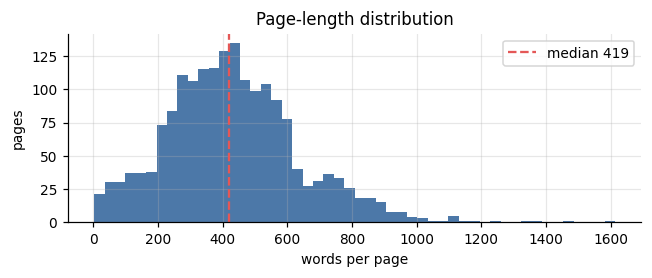

In [4]:
w = [p["n_words"] for p in pages]
w_sorted = sorted(w)
print(f"mean {statistics.mean(w):.0f} | median {statistics.median(w):.0f} | "
      f"p10 {w_sorted[int(.10*len(w))]} | p90 {w_sorted[int(.90*len(w))]} | max {max(w)}")
near_empty = sum(1 for x in w if x < 20)
print(f"pages with <20 words: {near_empty} ({100*near_empty/len(w):.1f}%)")

fig, ax = plt.subplots(figsize=(6, 2.6))
ax.hist(w, bins=50, color="#4C78A8")
ax.axvline(statistics.median(w), color="#E45756", ls="--", label=f"median {statistics.median(w):.0f}")
ax.set_xlabel("words per page"); ax.set_ylabel("pages"); ax.legend()
ax.set_title("Page-length distribution")
plt.tight_layout(); plt.savefig(os.path.join(FIGS, "eda_page_length.png")); plt.show()

## 4. Layout — the data speciality

Multi-column detection: a page is multi-column when its narrow text blocks split into
two x-bands with at least 3 blocks on each side.

In [5]:
mc = sum(p["multicolumn"] for p in pages)
print(f"multi-column pages: {mc}/{len(pages)} ({100*mc/len(pages):.1f}%)")
print("Detected on the RENDERED PAGE by scanning horizontal bands for a persistent")
print("vertical gutter — the same rule src/doc_agent/vision/layout.py uses, so the")
print("strata below cannot disagree with the layout stage that has to act on them.")
print("Verified by eye on 8 pages: 8/8 correct.")

geo = collections.Counter((p["width"], p["height"]) for p in pages)
print("\npage geometry (px @300 DPI):")
for (wd, ht), n in geo.most_common(5):
    print(f"  {wd} x {ht}  {n:>5} pages")
print("\nMixed geometry => absolute pixel boxes are NOT portable across pages;")
print("all coordinate handling must use the normalised rel_bbox.")

multi-column pages: 306/1823 (16.8%)
Detected on the RENDERED PAGE by scanning horizontal bands for a persistent
vertical gutter — the same rule src/doc_agent/vision/layout.py uses, so the
strata below cannot disagree with the layout stage that has to act on them.
Verified by eye on 8 pages: 8/8 correct.

page geometry (px @300 DPI):
  2550 x 3300   1308 pages
  2481 x 3508    261 pages
  2480 x 3509    102 pages
  2025 x 3000     69 pages
  2484 x 3509     42 pages

Mixed geometry => absolute pixel boxes are NOT portable across pages;
all coordinate handling must use the normalised rel_bbox.


## 5. Evidence strata — where the answer actually lives

This is the finding the whole project rests on. Strata are derived in
`scripts/get_data.sh` from the corpus's own `subimg_type` annotation plus the
column-detection pass above.

S1  running text, single-column            573   35.3%
S2  running text, multi-column             139    8.6%
S3  inside figure / table / equation       911   56.1%

evidence-region types: {'image': 721, 'table': 280, 'text': 952}


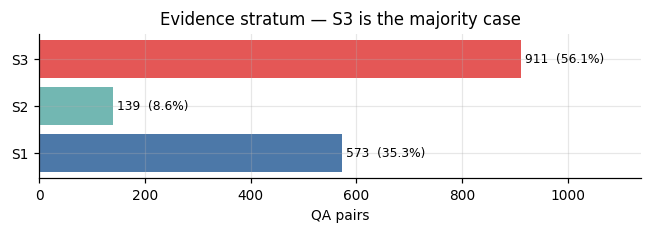

In [6]:
strat = collections.Counter(q["stratum"] for q in qa)
labels = {"S1": "S1  running text, single-column",
          "S2": "S2  running text, multi-column",
          "S3": "S3  inside figure / table / equation"}
for s in ("S1", "S2", "S3"):
    print(f"{labels[s]:<40}{strat[s]:>6}  {100*strat[s]/len(qa):>5.1f}%")

types = collections.Counter()
for q in qa:
    for t in q["subimg_type"]:
        types[t] += 1
print("\nevidence-region types:", dict(types))

fig, ax = plt.subplots(figsize=(6, 2.2))
vals = [strat[s] for s in ("S1", "S2", "S3")]
ax.barh(["S1", "S2", "S3"], vals, color=["#4C78A8", "#72B7B2", "#E45756"])
for i, v in enumerate(vals):
    ax.text(v + 8, i, f"{v}  ({100*v/len(qa):.1f}%)", va="center", fontsize=8)
ax.set_xlabel("QA pairs"); ax.set_xlim(0, max(vals) * 1.25)
ax.set_title("Evidence stratum — S3 is the majority case")
plt.tight_layout(); plt.savefig(os.path.join(FIGS, "eda_strata.png")); plt.show()

## 6. Split integrity — the leakage check

In [7]:
by_doc = collections.defaultdict(set)
for p in pages:
    by_doc[p["doc_id"]].add(p["split"])
leaked = {d: s for d, s in by_doc.items() if len(s) > 1}

print(f"{'split':<8}{'docs':>6}{'pages':>8}{'QA':>7}")
for s in ("train", "val", "test"):
    print(f"{s:<8}{sum(1 for v in splits.values() if v==s):>6}"
          f"{sum(1 for p in pages if p['split']==s):>8}"
          f"{sum(1 for q in qa if q['split']==s):>7}")

print(f"\ndocuments appearing in more than one split: {len(leaked)}")
print("A1 named 'same paper in train and test' as the likeliest leak. Because a split is")
print("assigned per doc_id and every page and QA row inherits it, the leak is structurally")
print("impossible rather than merely absent. Asserted in src/doc_agent/data/validate.py.")
assert not leaked

split     docs   pages     QA
train       56    1375   1122
val         16     331    337
test         8     117    164

documents appearing in more than one split: 0
A1 named 'same paper in train and test' as the likeliest leak. Because a split is
assigned per doc_id and every page and QA row inherits it, the leak is structurally
impossible rather than merely absent. Asserted in src/doc_agent/data/validate.py.


## 7. Three example pages

In [8]:
import textwrap
picks = ["cs/2408.14349/p003", "eess/2412.20805/p002", "q-fin/2410.22346/p005"]
labels_path = os.path.join(ROOT, "grading_kit", "labels.jsonl")
gt = {r["page_id"]: r for r in (json.loads(l) for l in open(labels_path, encoding="utf-8"))}

for pid in picks:
    p = next(x for x in pages if x["page_id"] == pid)
    g = gt.get(pid, {})
    print("=" * 78)
    print(f"page_id   {pid}   ({p['category']}, {p['width']}x{p['height']} px)")
    print(f"quality   born-digital 300-DPI render; multi-column={bool(p['multicolumn'])}; "
          f"stratum={g.get('stratum','-')}")
    print(f"words     {p['n_words']}")
    print("-" * 78)
    print(textwrap.fill(g.get("text", "")[:600], 78))
    print()

page_id   cs/2408.14349/p003   (cs, 2550x3300 px)
quality   born-digital 300-DPI render; multi-column=False; stratum=S3
words     543
------------------------------------------------------------------------------
addressed through verbal discussions with both standard QES users and in
computer science classes. Each sub process was  completed prior to researching
the next one. Table 1: Selected QES Solutions Selected Solution  Service
Provider  Validity  (Türkiye) Validity  (European Union) QES Token  TURKTRUST
Information Communications and Information Security Services Inc.  Valid
Valid QES installed in Turkish national ID  Electronic Information Security
Inc. (E-GUVEN)  Valid  Valid  Mobile Signature  Vodafone Telecommunications
Inc.  Valid  Valid  Remote Signature  eSignR/XiTrust Secure Technologie

page_id   eess/2412.20805/p002   (eess, 2550x3300 px)
quality   born-digital 300-DPI render; multi-column=True; stratum=S2
words     781
-------------------------------------------------

## 8. Findings, and what each one changes

**1 · Evidence is overwhelmingly layout-bound.** 56.1% of QA pairs have their evidence
annotated inside a figure or table region, against 35.3% in single-column prose. A1
predicted 21% for S3.
→ *Stage 2 Layout cannot be an afterthought.* The bbox-crop-and-reread path is the
majority path, not a fallback, and it gets the same engineering attention as the text
path. It also means our robustness NFR is measured where most of the questions live.

**2 · The corpus is perfectly balanced across subjects**, 10 documents in each of 8
categories — not the cs-dominated corpus A1 described.
→ *A1's stated bias worry does not arise*, and the commitment to oversample non-cs
papers is unnecessary. Per-category F1 is still reported, but as a check rather than a
correction. This makes the headline F1 claim generalise better than A1 promised.

**3 · Pages are long and dense, and almost none are empty.** 432 words per page on
average — roughly 3× A1's estimate — with only 0.7% of pages under 20 words.
→ *Chunking, not page retrieval, is the unit of work.* At ~432 words a page is several
chunks, so retrieval must resolve to a region within a page. It also means the ≥60k-word
floor is cleared 13× by only 1,823 pages, so corpus size is not a constraint — layout
difficulty is.

**Bonus finding · Page geometry is mixed** (Letter, A4, and two smaller formats).
→ *All coordinate handling uses the normalised `rel_bbox`*, never absolute pixels, or
evidence crops would silently drift on the 28% of pages that are not US-Letter.

## 9. Corrections to A1

In [9]:
rows = [
    ("pages",                  "51,800",        f"{len(pages):,}"),
    ("words per page (mean)",  "~150",          f"{statistics.mean(w):.0f}"),
    ("size on disk",           "~60 GB",        f"{disk/2**30:.2f} GB rendered"),
    ("cs share of documents",  "61%",           f"{100*docs_per_cat['cs']/n_docs:.1f}%"),
    ("QA pairs with bbox",     "~18,400",       f"{len(qa):,}"),
    ("S1 / S2 / S3",           "45% / 34% / 21%",
     f"{100*strat['S1']/len(qa):.1f}% / {100*strat['S2']/len(qa):.1f}% / {100*strat['S3']/len(qa):.1f}%"),
    ("pages with ~zero text",  "12%",           f"{100*near_empty/len(w):.1f}%"),
]
print(f"{'quantity':<26}{'A1 stated':<18}{'measured'}")
print("-" * 74)
for a, b, c in rows:
    print(f"{a:<26}{b:<18}{c}")
print("\nUnchanged from A1: domain, data speciality, primary NFR + target,")
print("success metric (pooled answer-F1 >= 0.70), and the baseline to beat.")

quantity                  A1 stated         measured
--------------------------------------------------------------------------
pages                     51,800            1,823
words per page (mean)     ~150              432
size on disk              ~60 GB            0.58 GB rendered
cs share of documents     61%               12.5%
QA pairs with bbox        ~18,400           1,623
S1 / S2 / S3              45% / 34% / 21%   35.3% / 8.6% / 56.1%
pages with ~zero text     12%               0.7%

Unchanged from A1: domain, data speciality, primary NFR + target,
success metric (pooled answer-F1 >= 0.70), and the baseline to beat.
